In [1]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Memememe@07",
    database="cart2insights"
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [2]:
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
sellers = pd.read_sql("SELECT * FROM sellers", conn)
products = pd.read_sql("SELECT * FROM products", conn)
order_payments = pd.read_sql("SELECT * FROM order_payments", conn)
order_reviews = pd.read_sql("SELECT * FROM order_reviews", conn)
product_category = pd.read_sql("SELECT * FROM product_category", conn)

print("Data loaded successfully!")

C:\Users\Siddarth.b\AppData\Local\Temp\ipykernel_24060\3135988534.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\Siddarth.b\AppData\Local\Temp\ipykernel_24060\3135988534.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", conn)
C:\Users\Siddarth.b\AppData\Local\Temp\ipykernel_24060\3135988534.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)
C:\Use

Data loaded successfully!


C:\Users\Siddarth.b\AppData\Local\Temp\ipykernel_24060\3135988534.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_category = pd.read_sql("SELECT * FROM product_category", conn)


In [14]:
# Convert date columns to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

# Calculate delivery days
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

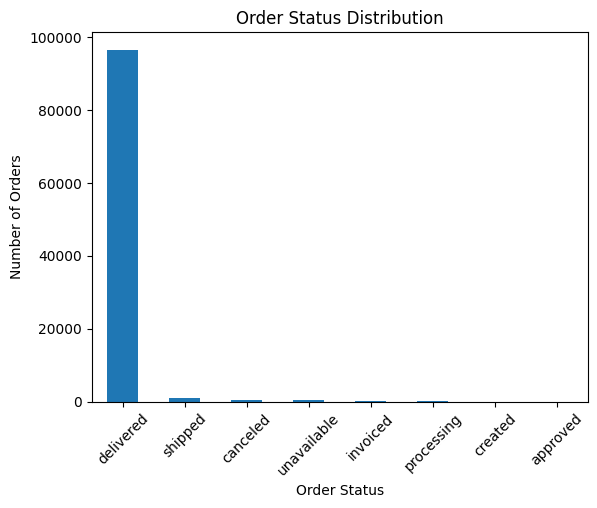

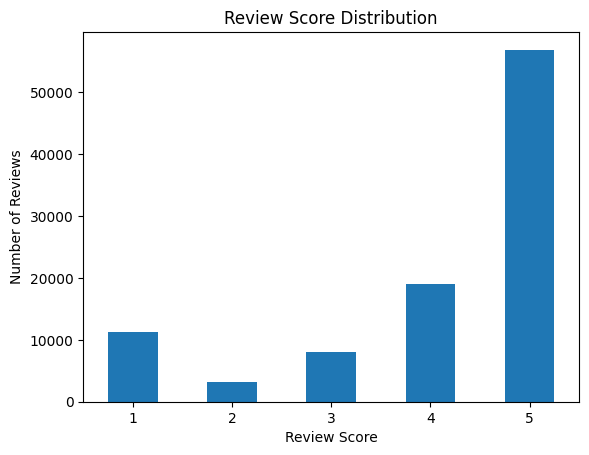

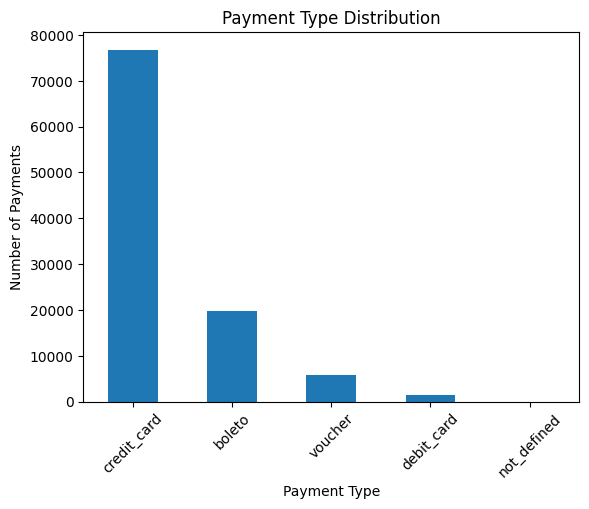

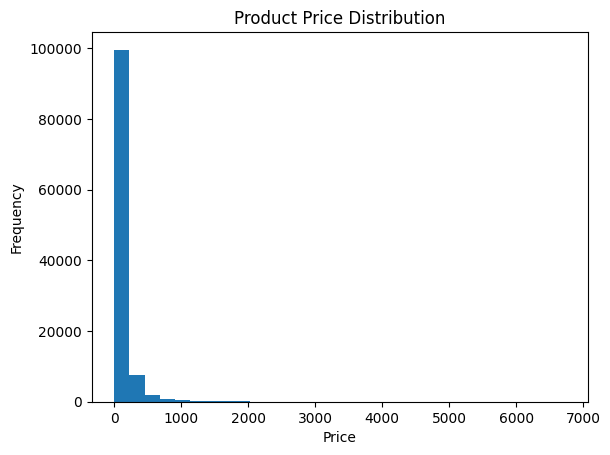

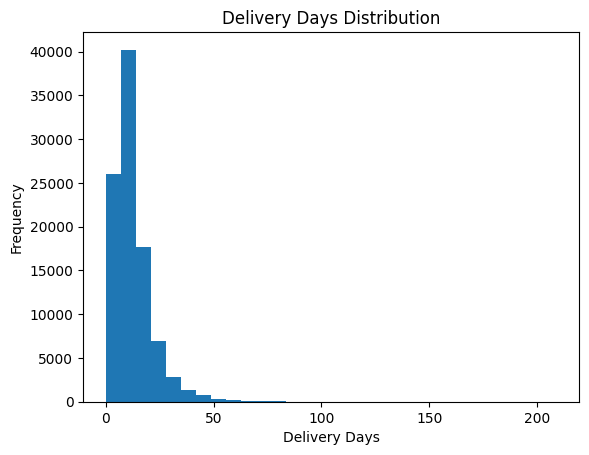

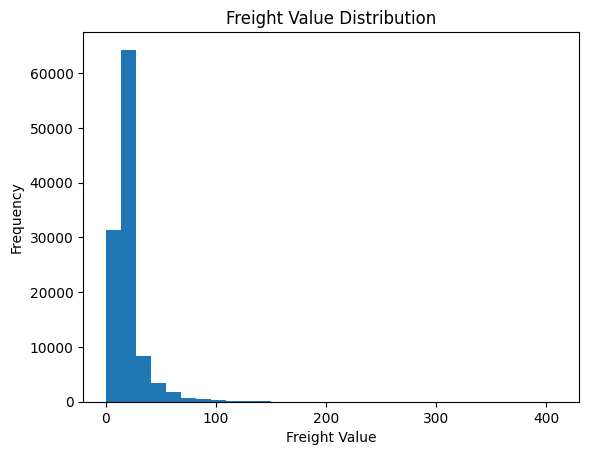

In [15]:
import matplotlib.pyplot as plt

# 1. Order Status Distribution
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


# 2. Review Score Distribution
order_reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


# 3. Payment Type Distribution
order_payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.show()


# 4. Product Price Distribution
order_items["price"].plot(kind="hist", bins=30)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# 5. Delivery Days Distribution
orders["delivery_days"].plot(kind="hist", bins=30)
plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()


# 6. Freight Value Distribution
order_items["freight_value"].plot(kind="hist", bins=30)
plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.show()

In [18]:
# Create Total Order Value

order_items["item_total"] = (
    order_items["price"] + order_items["freight_value"]
)

order_value = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

order_value.rename(
    columns={"item_total": "total_order_value"},
    inplace=True
)

print(order_value.head())

                           order_id  total_order_value
0  00010242fe8c5a6d1ba2dd792cb16214              72.19
1  00018f77f2f0320c557190d7a144bdd3             259.83
2  000229ec398224ef6ca0657da4fc703e             216.87
3  00024acbcdf0a6daa1e931b038114c75              25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9             218.04


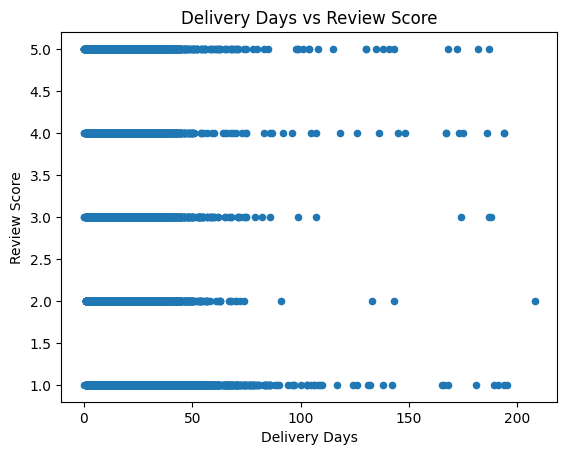

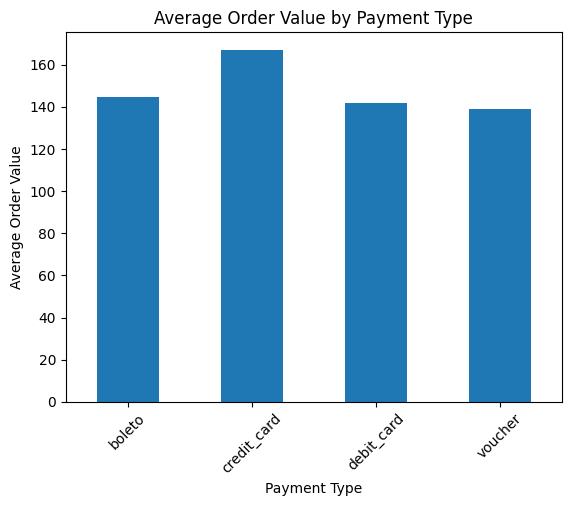

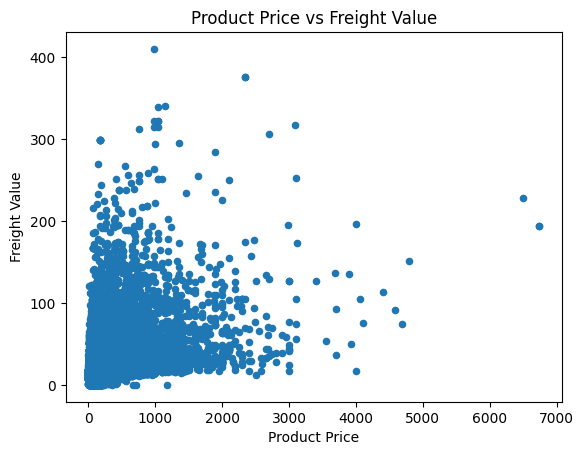

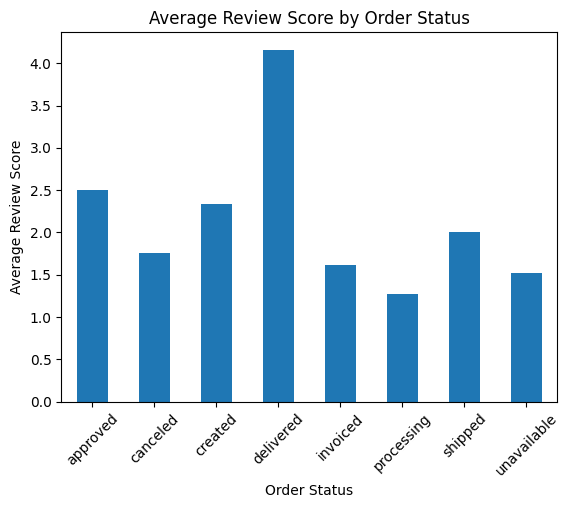

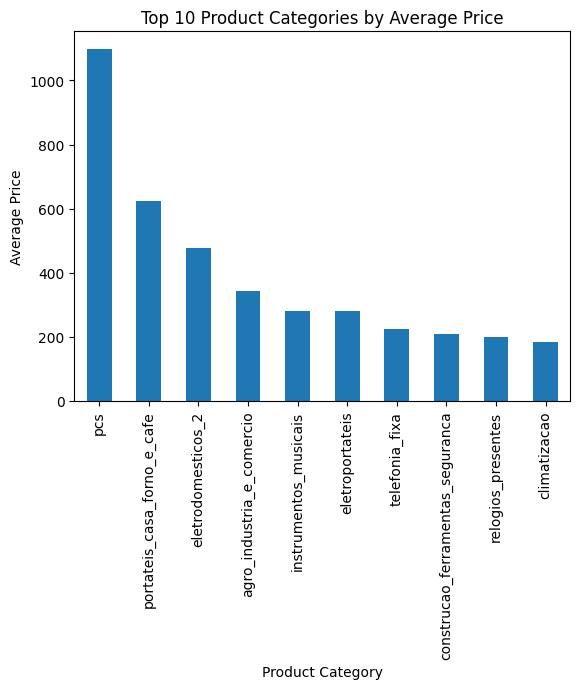

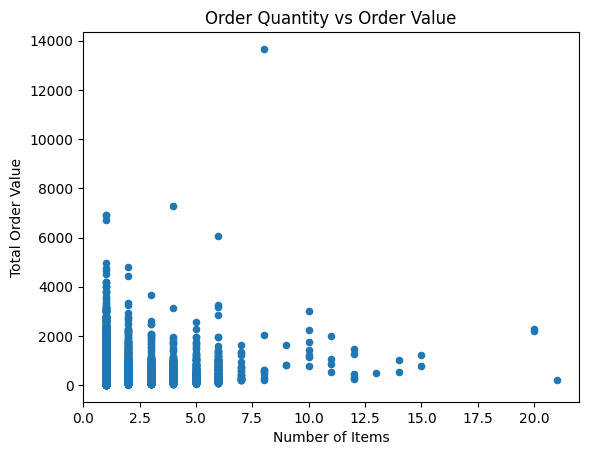

In [19]:
# 1. Delivery Days vs Review Score
delivery_review = orders[
    ["order_id", "delivery_days"]
].merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

delivery_review.plot(
    kind="scatter",
    x="delivery_days",
    y="review_score"
)

plt.title("Delivery Days vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.show()


# 2. Payment Type vs Order Value
payment_order = order_payments.merge(
    order_value,
    on="order_id",
    how="inner"
)

payment_order.groupby("payment_type")["total_order_value"].mean().plot(
    kind="bar"
)

plt.title("Average Order Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()


# 3. Product Price vs Freight Value
order_items.plot(
    kind="scatter",
    x="price",
    y="freight_value"
)

plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.show()


# 4. Order Status vs Review Score
status_review = orders[
    ["order_id", "order_status"]
].merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

status_review.groupby("order_status")["review_score"].mean().plot(
    kind="bar"
)

plt.title("Average Review Score by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.show()


# 5. Product Category vs Order Value
category_order = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_order.groupby("product_category_name")["price"].mean().sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Average Price")
plt.xlabel("Product Category")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.show()


# 6. Order Quantity vs Order Value
order_quantity = (
    order_items.groupby("order_id")
    .size()
    .reset_index(name="order_quantity")
)

quantity_value = order_quantity.merge(
    order_value,
    on="order_id",
    how="inner"
)

quantity_value.plot(
    kind="scatter",
    x="order_quantity",
    y="total_order_value"
)

plt.title("Order Quantity vs Order Value")
plt.xlabel("Number of Items")
plt.ylabel("Total Order Value")
plt.show()

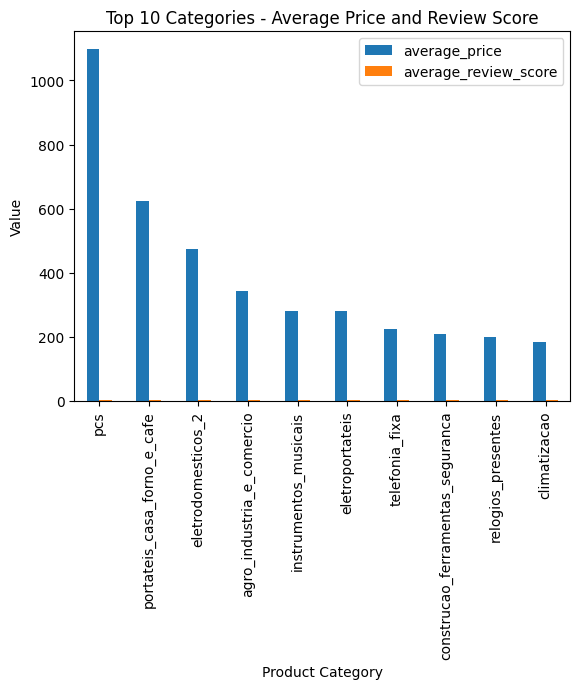

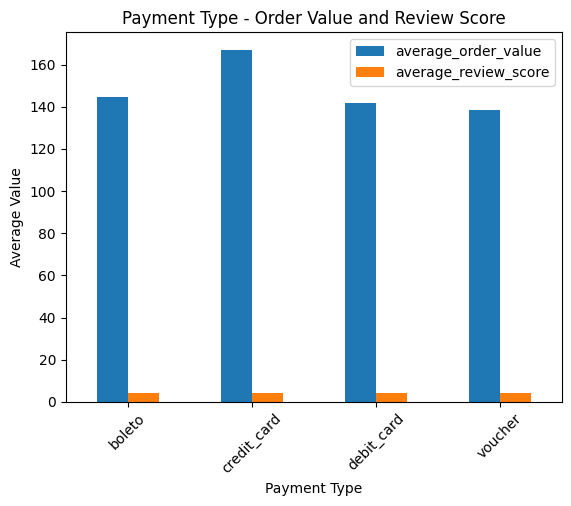

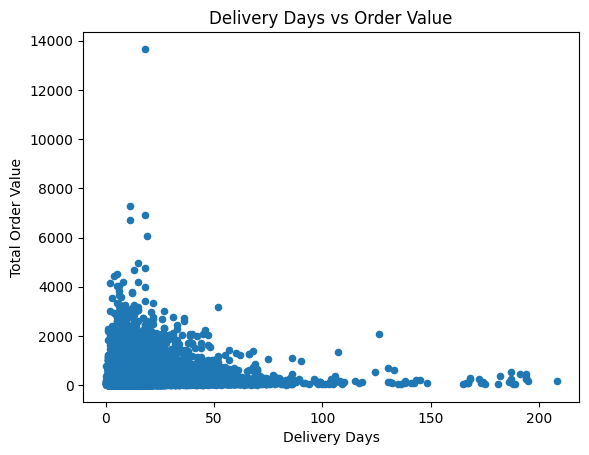

In [20]:
# 1. Category, Price and Review Score
category_review = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
).merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

category_review.groupby("product_category_name").agg(
    average_price=("price", "mean"),
    average_review_score=("review_score", "mean")
).sort_values(
    "average_price",
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title("Top 10 Categories - Average Price and Review Score")
plt.xlabel("Product Category")
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.show()


# 2. Payment Type, Order Value and Review Score
payment_review = payment_order.merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

payment_review.groupby("payment_type").agg(
    average_order_value=("total_order_value", "mean"),
    average_review_score=("review_score", "mean")
).plot(
    kind="bar"
)

plt.title("Payment Type - Order Value and Review Score")
plt.xlabel("Payment Type")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()


# 3. Delivery Days, Order Value and Review Score
delivery_value_review = delivery_review.merge(
    order_value,
    on="order_id",
    how="inner"
)

delivery_value_review.plot(
    kind="scatter",
    x="delivery_days",
    y="total_order_value"
)

plt.title("Delivery Days vs Order Value")
plt.xlabel("Delivery Days")
plt.ylabel("Total Order Value")
plt.show()

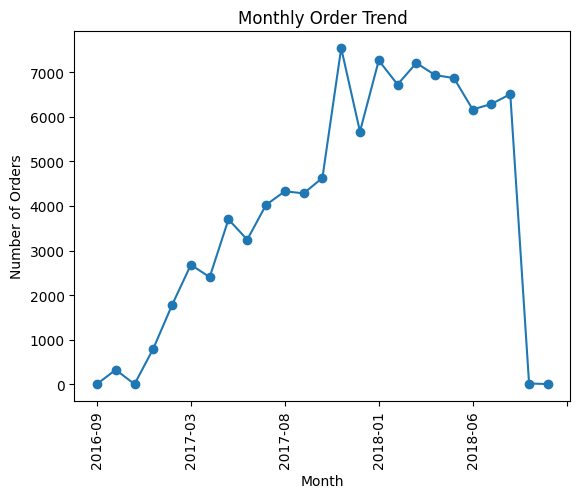

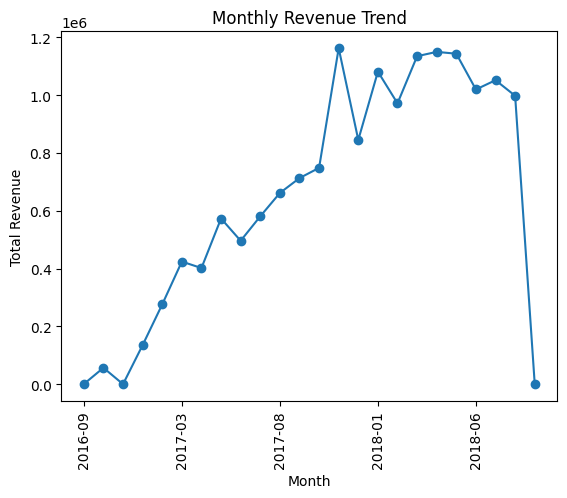

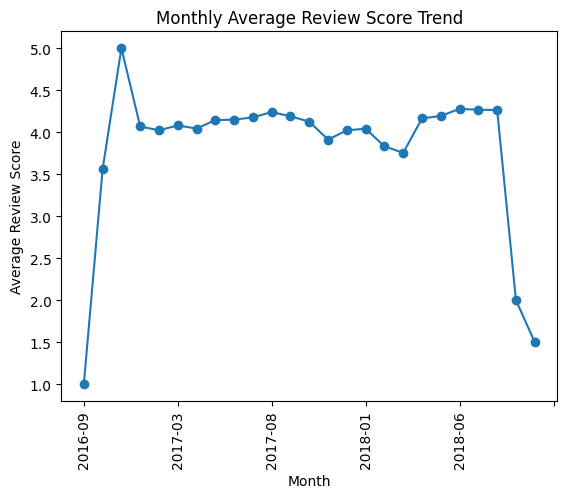

In [21]:
# Create month column
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)


# 1. Monthly Order Trend
monthly_orders = (
    orders.groupby("month")["order_id"]
    .count()
)

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.show()


# 2. Monthly Revenue Trend
monthly_revenue = order_value.merge(
    orders[["order_id", "month"]],
    on="order_id",
    how="inner"
).groupby("month")["total_order_value"].sum()

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()


# 3. Monthly Average Review Score
monthly_reviews = orders[
    ["order_id", "month"]
].merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
).groupby("month")["review_score"].mean()

monthly_reviews.plot(kind="line", marker="o")

plt.title("Monthly Average Review Score Trend")
plt.xlabel("Month")
plt.ylabel("Average Review Score")
plt.xticks(rotation=90)
plt.show()

                     total_order_value  delivery_days  delivery_delay_days  \
total_order_value             1.000000       0.068799            -0.017729   
delivery_days                 0.068799       1.000000             0.606519   
delivery_delay_days          -0.017729       0.606519             1.000000   
order_quantity                0.189891      -0.019417            -0.032150   
review_score                 -0.046705      -0.335060            -0.266842   

                     order_quantity  review_score  
total_order_value          0.189891     -0.046705  
delivery_days             -0.019417     -0.335060  
delivery_delay_days       -0.032150     -0.266842  
order_quantity             1.000000     -0.114632  
review_score              -0.114632      1.000000  


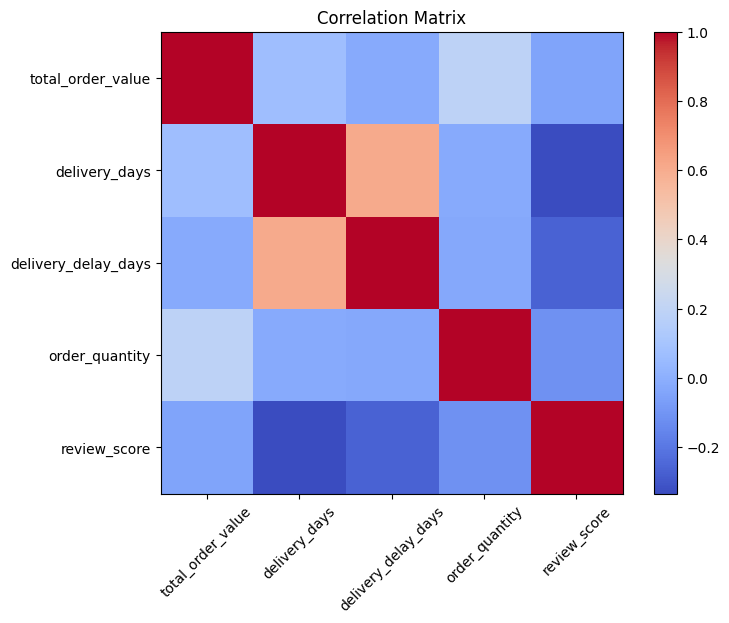

In [23]:
# Create delivery delay
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days


# Create order-level review score
review_by_order = (
    order_reviews.groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)


# Create order-level quantity
order_quantity = (
    order_items.groupby("order_id")
    .size()
    .reset_index(name="order_quantity")
)


# Combine important numerical variables
correlation_data = (
    order_value
    .merge(
        orders[
            [
                "order_id",
                "delivery_days",
                "delivery_delay_days"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        order_quantity,
        on="order_id",
        how="left"
    )
    .merge(
        review_by_order,
        on="order_id",
        how="left"
    )
)


# Create correlation matrix
correlation_matrix = correlation_data[
    [
        "total_order_value",
        "delivery_days",
        "delivery_delay_days",
        "order_quantity",
        "review_score"
    ]
].corr()

print(correlation_matrix)


# Display correlation matrix
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

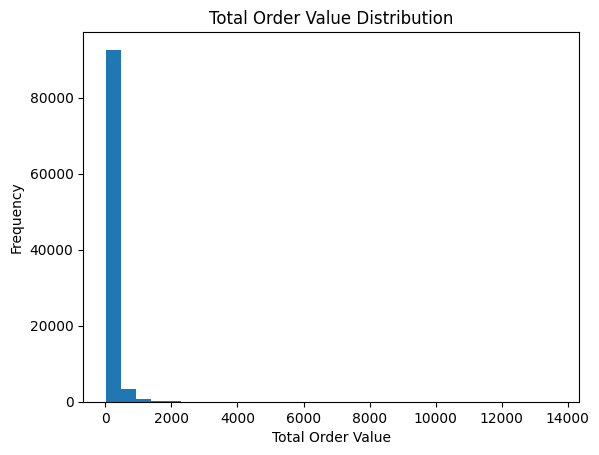

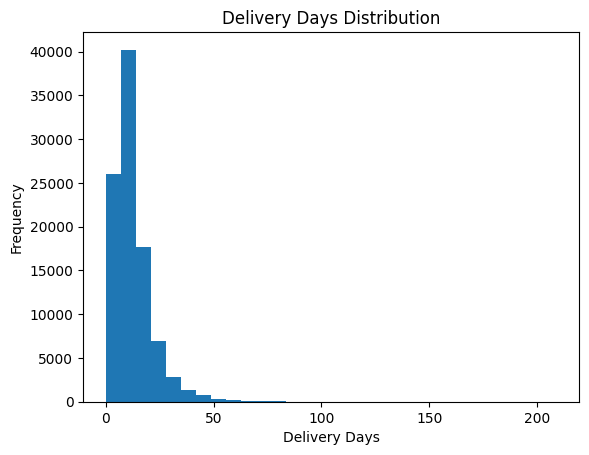

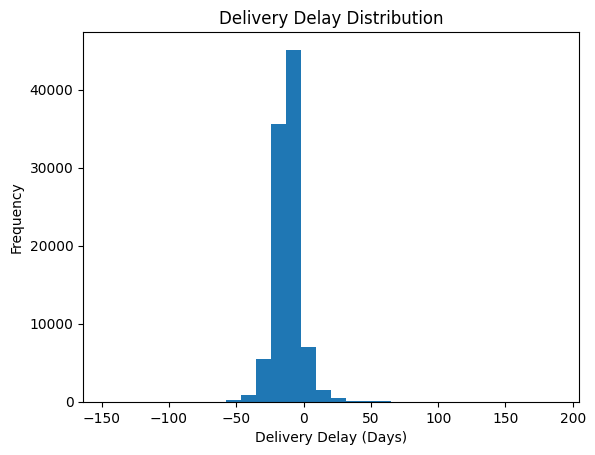

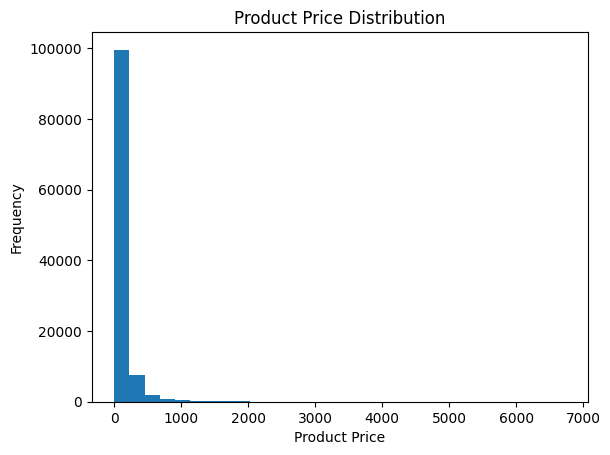

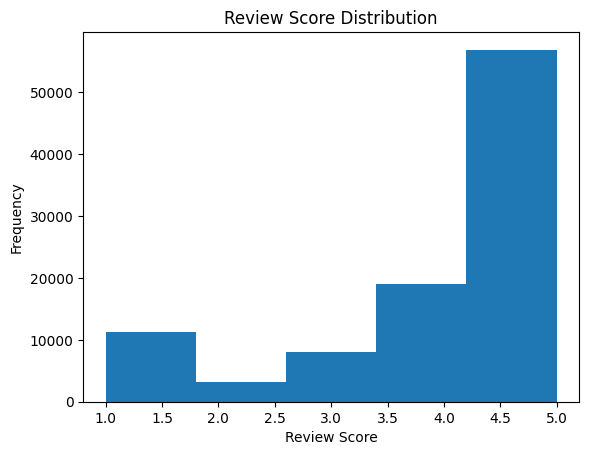

In [24]:
# 1. Order Value Distribution
order_value["total_order_value"].plot(
    kind="hist",
    bins=30
)

plt.title("Total Order Value Distribution")
plt.xlabel("Total Order Value")
plt.ylabel("Frequency")
plt.show()


# 2. Delivery Days Distribution
orders["delivery_days"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()


# 3. Delivery Delay Distribution
orders["delivery_delay_days"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("Delivery Delay Distribution")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Frequency")
plt.show()


# 4. Product Price Distribution
order_items["price"].plot(
    kind="hist",
    bins=30
)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Frequency")
plt.show()


# 5. Review Score Distribution
order_reviews["review_score"].plot(
    kind="hist",
    bins=5
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Frequency")
plt.show()